In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
import glob
import re
import os

# ================= USER SETTINGS =================
BASE_DIR = "./"
VIDEO_OUTFILE = "cumulative_1p8GHz_detection_from_inst.mp4"

# Match the acquisition preview x-axis
TOTAL_BW_GHZ = 2.4576

SIG_FREQ_GHZ = 1.8
F_VIDEO_WINDOW_GHZ = (1.75, 1.85)

FPS = 4
DPI = 150

REMOVE_BASELINE = True
POLY_ORDER = 3

# ----- Signal / sideband settings -----
SIGNAL_SEARCH_HALF_WIDTH_GHZ = 0.001   # 1 MHz around signal
GUARD_HALF_WIDTH_GHZ = 0.001           # exclude ±1 MHz around signal
SIDEBAND_HALF_WIDTH_GHZ = 0.005        # use ±5 MHz sidebands
# =================================================


# ---------- LOAD CSV DATASET ----------
def load_dataset_csv(base_dir, use_column="inst"):
    files = sorted(glob.glob(os.path.join(base_dir, "*.csv")))
    if not files:
        raise RuntimeError("No .csv files found")

    rec = []
    for f in files:
        name = os.path.basename(f)

        if name.upper() == "FINAL.CSV":
            continue

        m = re.search(r"t(\d+)s\.csv", name)
        if m:
            t = float(m.group(1))
            rec.append((t, f))
        else:
            print(f"Skipping unrecognized file: {f}")

    rec.sort(key=lambda x: x[0])

    spectra = []
    times = []
    n_bins = None

    col = 1 if use_column == "inst" else 2

    for t, f in rec:
        try:
            data = np.loadtxt(f, delimiter=",", skiprows=1)

            if data.ndim != 2 or data.shape[1] < 3:
                print(f"Skipping {f}: expected 3 columns (freq_Hz, inst_dBm, avg_dBm)")
                continue

            spec = data[:, col]

            if n_bins is None:
                n_bins = len(spec)

            if len(spec) != n_bins or np.any(np.isnan(spec)):
                print(f"Skipping {f}: bad spectrum length or NaNs")
                continue

            spectra.append(spec)
            times.append(t)

        except Exception as e:
            print(f"Skipping bad file {f}: {e}")

    spectra = np.array(spectra)
    times = np.array(times)

    if len(spectra) == 0:
        raise RuntimeError("No valid CSV spectra loaded.")

    return times, spectra, n_bins


# ---------- REBUILD FREQUENCY AXIS ----------
def build_frequency_axis_ghz(n_bins, total_bw_ghz):
    return np.linspace(0, total_bw_ghz, n_bins, endpoint=False)


# ---------- BASELINE REMOVAL ----------
def remove_baseline_1d(y, order=3):
    x = np.arange(len(y))
    p = np.polyfit(x, y, order)
    baseline = np.polyval(p, x)
    return y - baseline, baseline


# ---------- CUMULATIVE AVERAGE ----------
def cumulative_average(spectra):
    csum = np.cumsum(spectra, axis=0)
    n = np.arange(1, len(spectra) + 1)[:, None]
    return csum / n


# ---------- MAIN VIDEO ----------
def make_cumulative_video(F, spectra, times, outfile, window, remove_baseline=True):
    # ----- Plotting window -----
    f0, f1 = window
    mask_plot = (F >= f0) & (F <= f1)

    if np.sum(mask_plot) == 0:
        raise RuntimeError(f"No bins inside plot window {window}")

    Fw = F[mask_plot]
    Sw = spectra[:, mask_plot]

    # ----- cumulative average across all saved frames -----
    Sw_cum = cumulative_average(Sw)

    # ----- signal / sideband masks -----
    signal_search_mask = (
        (Fw >= SIG_FREQ_GHZ - SIGNAL_SEARCH_HALF_WIDTH_GHZ) &
        (Fw <= SIG_FREQ_GHZ + SIGNAL_SEARCH_HALF_WIDTH_GHZ)
    )

    left_sideband_mask = (
        (Fw >= SIG_FREQ_GHZ - SIDEBAND_HALF_WIDTH_GHZ) &
        (Fw <  SIG_FREQ_GHZ - GUARD_HALF_WIDTH_GHZ)
    )

    right_sideband_mask = (
        (Fw >  SIG_FREQ_GHZ + GUARD_HALF_WIDTH_GHZ) &
        (Fw <= SIG_FREQ_GHZ + SIDEBAND_HALF_WIDTH_GHZ)
    )

    baseline_mask = left_sideband_mask | right_sideband_mask

    if np.sum(signal_search_mask) < 1:
        raise RuntimeError("Signal search window contains no bins.")
    if np.sum(baseline_mask) < 10:
        raise RuntimeError("Sideband baseline window contains too few bins.")

    processed = []
    baseline_vals = []
    sigma_vals = []
    peak_vals = []
    peak_freqs = []
    excess_vals = []
    snr_vals = []

    for row in Sw_cum:
        if remove_baseline:
            resid, baseline_curve = remove_baseline_1d(row, POLY_ORDER)
            y = resid
        else:
            y = row.copy()

        sideband_vals = y[baseline_mask]
        baseline_mean = np.mean(sideband_vals)
        baseline_sigma = np.std(sideband_vals)

        sig_vals = y[signal_search_mask]
        sig_freqs = Fw[signal_search_mask]
        peak_idx = np.argmax(sig_vals)

        peak_val = sig_vals[peak_idx]
        peak_freq = sig_freqs[peak_idx]

        excess = peak_val - baseline_mean
        snr = excess / baseline_sigma if baseline_sigma > 0 else np.nan

        processed.append(y)
        baseline_vals.append(baseline_mean)
        sigma_vals.append(baseline_sigma)
        peak_vals.append(peak_val)
        peak_freqs.append(peak_freq)
        excess_vals.append(excess)
        snr_vals.append(snr)

    Sw_plot = np.array(processed)
    baseline_vals = np.array(baseline_vals)
    sigma_vals = np.array(sigma_vals)
    peak_vals = np.array(peak_vals)
    peak_freqs = np.array(peak_freqs)
    excess_vals = np.array(excess_vals)
    snr_vals = np.array(snr_vals)

    crossed = snr_vals >= 5

    # ----- Plot limits -----
    ymin = np.nanmin(Sw_plot)
    ymax = np.nanmax(Sw_plot)
    pad = 0.12 * (ymax - ymin if ymax > ymin else 1)
    ymin -= pad
    ymax += pad

    fig, ax = plt.subplots(figsize=(11, 6))

    line_spec, = ax.plot([], [], lw=1.5, label="Cumulative Average Spectrum")
    line_baseline, = ax.plot([], [], "--", lw=1.5, label="Local Sideband Mean")
    signal_dot, = ax.plot([], [], 'ro', ms=8, label="Detected Peak")
    sig_vline = ax.axvline(SIG_FREQ_GHZ, linestyle=':', linewidth=1.8, label="Expected Signal (1.8 GHz)")

    txt_time = ax.text(
        0.02, 0.97, "", transform=ax.transAxes,
        ha='left', va='top', fontsize=12,
        bbox=dict(facecolor='white', alpha=0.88)
    )

    txt_stats = ax.text(
        0.02, 0.72, "", transform=ax.transAxes,
        ha='left', va='top', fontsize=12,
        bbox=dict(facecolor='white', alpha=0.88)
    )

    ax.set_xlim(Fw.min(), Fw.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Residual Power (dB)" if remove_baseline else "Power (dBm)")
    ax.set_title("Cumulative Averaged Spectrum Near 1.8 GHz")
    ax.legend(loc="upper right")

    def init():
        line_spec.set_data([], [])
        line_baseline.set_data([], [])
        signal_dot.set_data([], [])
        txt_time.set_text("")
        txt_stats.set_text("")
        return line_spec, line_baseline, signal_dot, txt_time, txt_stats

    def update(i):
        y = Sw_plot[i]
        baseline_line = np.full(Fw.shape, baseline_vals[i])

        line_spec.set_data(Fw, y)
        line_baseline.set_data(Fw, baseline_line)
        signal_dot.set_data([peak_freqs[i]], [peak_vals[i]])

        txt_time.set_text(
            f"t = {times[i]/3600:.2f} h\n"
            f"elapsed = {times[i]:.0f} s"
        )

        crossed_text = "YES" if crossed[i] else "NO"
        txt_stats.set_text(
            f"N avg = {i+1}\n"
            f"Peak freq = {peak_freqs[i]:.6f} GHz\n"
            f"Peak power = {peak_vals[i]:.3f} dBm\n"
            f"Baseline mean = {baseline_vals[i]:.3f} dBm\n"
            f"Signal excess = {excess_vals[i]:.3f} dB\n"
            f"σ(sidebands) = {sigma_vals[i]:.3f} dB\n"
            f"SNR = {snr_vals[i]:.2f}\n"
            f"5σ crossed: {crossed_text}"
        )

        return line_spec, line_baseline, signal_dot, txt_time, txt_stats

    ani = FuncAnimation(
        fig,
        update,
        frames=len(times),
        init_func=init,
        blit=False
    )

    try:
        writer = FFMpegWriter(fps=FPS)
        ani.save(outfile, writer=writer, dpi=DPI)
        print(f"Saved video: {outfile}")
    except Exception as e:
        print("FFmpeg failed, saving GIF instead...")
        gif_out = outfile.replace(".mp4", ".gif")
        ani.save(gif_out, writer=PillowWriter(fps=FPS), dpi=DPI)
        print(f"Saved GIF: {gif_out}")
        print("Original ffmpeg error:", e)

    plt.close(fig)

    # ----- Summary -----
    print("\n===== SUMMARY =====")
    print(f"Loaded spectra: {len(times)}")
    print(f"Final detected peak freq: {peak_freqs[-1]:.9f} GHz")
    print(f"Final peak power: {peak_vals[-1]:.6f} dBm")
    print(f"Final baseline mean: {baseline_vals[-1]:.6f} dBm")
    print(f"Final signal excess: {excess_vals[-1]:.6f} dB")
    print(f"Final sigma(sidebands): {sigma_vals[-1]:.6f} dB")
    print(f"Final SNR: {snr_vals[-1]:.3f}")
    print(f"SNR min/max/mean: {np.nanmin(snr_vals):.3f} / {np.nanmax(snr_vals):.3f} / {np.nanmean(snr_vals):.3f}")

    if np.any(crossed):
        first_idx = np.argmax(crossed)
        print(f"First 5σ crossing at t = {times[first_idx]:.1f} s ({times[first_idx]/3600:.2f} h)")
    else:
        print("No 5σ crossing found.")


# ================= RUN =================
times, spectra, n_bins = load_dataset_csv(BASE_DIR, use_column="inst")
F = build_frequency_axis_ghz(n_bins, TOTAL_BW_GHZ)

print(f"Loaded {len(times)} spectra")
print(f"Frequency bins: {len(F)}")
print(f"Time span: {times[0]:.1f} s → {times[-1]:.1f} s")
print(f"Frequency range: {F.min():.6f} GHz → {F.max():.6f} GHz")

make_cumulative_video(
    F,
    spectra,
    times,
    outfile=VIDEO_OUTFILE,
    window=F_VIDEO_WINDOW_GHZ,
    remove_baseline=REMOVE_BASELINE
)

Loaded 95 spectra
Frequency bins: 262144
Time span: 300.0 s → 28572.0 s
Frequency range: 0.000000 GHz → 2.457591 GHz
Saved video: cumulative_1p8GHz_detection_from_inst.mp4

===== SUMMARY =====
Loaded spectra: 95
Final detected peak freq: 1.800037500 GHz
Final peak power: 15.354066 dBm
Final baseline mean: -0.047812 dBm
Final signal excess: 15.401879 dB
Final sigma(sidebands): 0.547632 dB
Final SNR: 28.125
SNR min/max/mean: 2.757 / 28.125 / 18.646
First 5σ crossing at t = 901.0 s (0.25 h)


Loaded 95 spectra
Frequency bins: 262144
Time span: 300.0 s → 28572.0 s
Frequency range: 0.000000 GHz → 2.457591 GHz


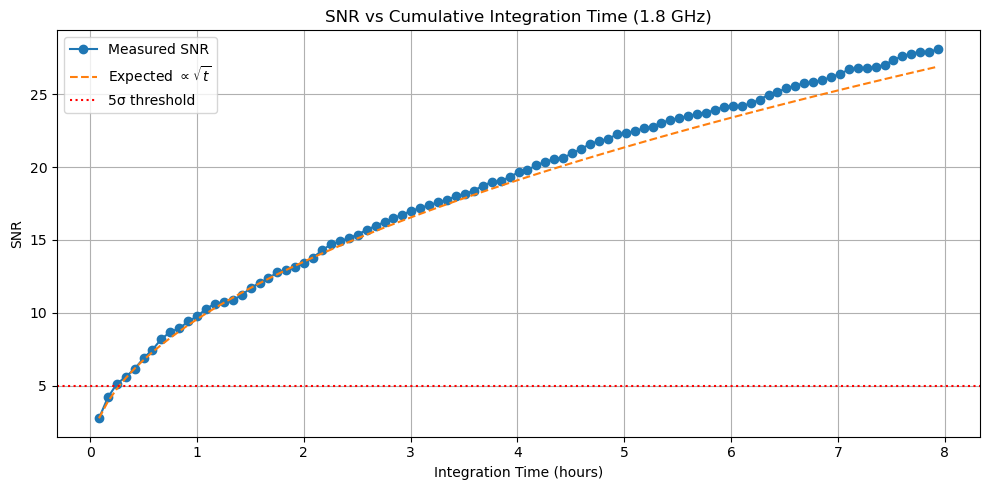

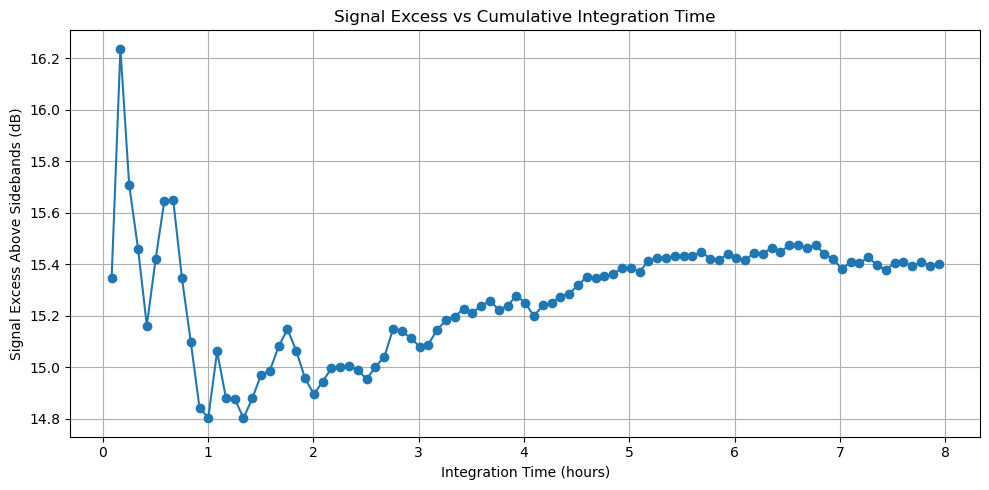

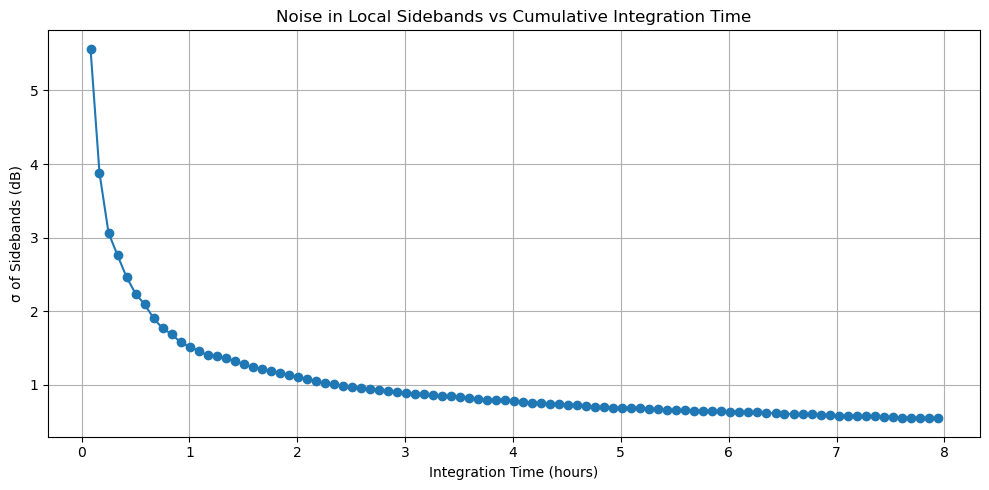

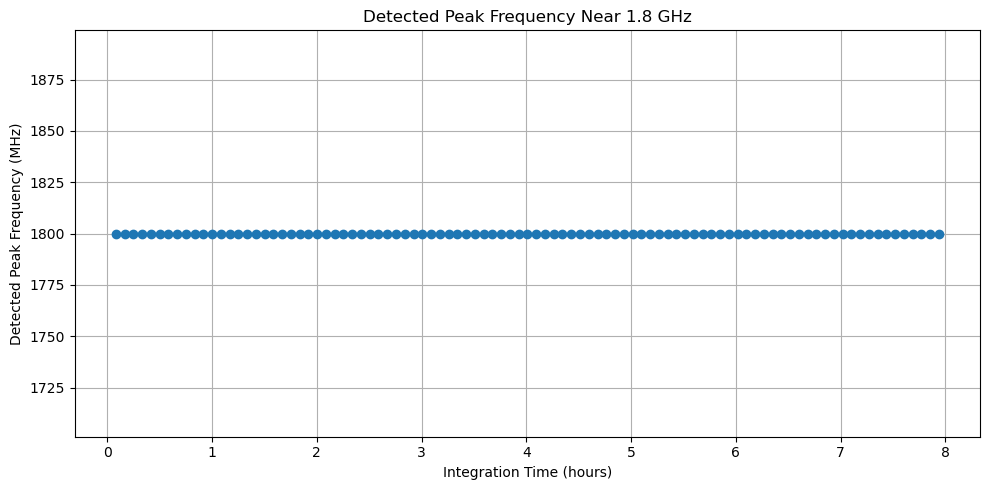


===== FINAL SUMMARY =====
Final SNR: 28.125
Max SNR: 28.125
Final signal excess: 15.402 dB
Final sideband sigma: 0.548 dB
Final peak frequency: 1.800037500 GHz


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
import os

# ================= USER SETTINGS =================
BASE_DIR = "./"

TOTAL_BW_GHZ = 2.4576
SIG_FREQ_GHZ = 1.8

# Window only used for analysis around signal
F_ANALYSIS_WINDOW_GHZ = (1.75, 1.85)

REMOVE_BASELINE = True
POLY_ORDER = 3

# ----- Signal / sideband settings -----
SIGNAL_SEARCH_HALF_WIDTH_GHZ = 0.001   # 1 MHz around signal
GUARD_HALF_WIDTH_GHZ = 0.001           # exclude ±1 MHz around signal
SIDEBAND_HALF_WIDTH_GHZ = 0.005        # use ±5 MHz sidebands
# =================================================


# ---------- LOAD CSV DATASET ----------
def load_dataset_csv(base_dir, use_column="inst"):
    files = sorted(glob.glob(os.path.join(base_dir, "*.csv")))
    if not files:
        raise RuntimeError("No .csv files found")

    rec = []
    for f in files:
        name = os.path.basename(f)

        if name.upper() == "FINAL.CSV":
            continue

        m = re.search(r"t(\d+)s\.csv", name)
        if m:
            t = float(m.group(1))
            rec.append((t, f))
        else:
            print(f"Skipping unrecognized file: {f}")

    rec.sort(key=lambda x: x[0])

    spectra = []
    times = []
    n_bins = None

    col = 1 if use_column == "inst" else 2

    for t, f in rec:
        try:
            data = np.loadtxt(f, delimiter=",", skiprows=1)

            if data.ndim != 2 or data.shape[1] < 3:
                print(f"Skipping {f}: expected 3 columns (freq_Hz, inst_dBm, avg_dBm)")
                continue

            spec = data[:, col]

            if n_bins is None:
                n_bins = len(spec)

            if len(spec) != n_bins or np.any(np.isnan(spec)):
                print(f"Skipping {f}: bad spectrum length or NaNs")
                continue

            spectra.append(spec)
            times.append(t)

        except Exception as e:
            print(f"Skipping bad file {f}: {e}")

    spectra = np.array(spectra)
    times = np.array(times)

    if len(spectra) == 0:
        raise RuntimeError("No valid CSV spectra loaded.")

    return times, spectra, n_bins


# ---------- REBUILD FREQUENCY AXIS ----------
def build_frequency_axis_ghz(n_bins, total_bw_ghz):
    return np.linspace(0, total_bw_ghz, n_bins, endpoint=False)


# ---------- BASELINE REMOVAL ----------
def remove_baseline_1d(y, order=3):
    x = np.arange(len(y))
    p = np.polyfit(x, y, order)
    baseline = np.polyval(p, x)
    return y - baseline, baseline


# ---------- CUMULATIVE AVERAGE ----------
def cumulative_average(spectra):
    csum = np.cumsum(spectra, axis=0)
    n = np.arange(1, len(spectra) + 1)[:, None]
    return csum / n


# ---------- COMPUTE SNR TRACK ----------
def compute_snr_track(F, spectra, times, analysis_window, remove_baseline=True):
    f0, f1 = analysis_window
    mask_plot = (F >= f0) & (F <= f1)

    if np.sum(mask_plot) == 0:
        raise RuntimeError(f"No bins inside analysis window {analysis_window}")

    Fw = F[mask_plot]
    Sw = spectra[:, mask_plot]

    Sw_cum = cumulative_average(Sw)

    signal_search_mask = (
        (Fw >= SIG_FREQ_GHZ - SIGNAL_SEARCH_HALF_WIDTH_GHZ) &
        (Fw <= SIG_FREQ_GHZ + SIGNAL_SEARCH_HALF_WIDTH_GHZ)
    )

    left_sideband_mask = (
        (Fw >= SIG_FREQ_GHZ - SIDEBAND_HALF_WIDTH_GHZ) &
        (Fw <  SIG_FREQ_GHZ - GUARD_HALF_WIDTH_GHZ)
    )

    right_sideband_mask = (
        (Fw >  SIG_FREQ_GHZ + GUARD_HALF_WIDTH_GHZ) &
        (Fw <= SIG_FREQ_GHZ + SIDEBAND_HALF_WIDTH_GHZ)
    )

    baseline_mask = left_sideband_mask | right_sideband_mask

    if np.sum(signal_search_mask) < 1:
        raise RuntimeError("Signal search window contains no bins.")
    if np.sum(baseline_mask) < 10:
        raise RuntimeError("Sideband baseline window contains too few bins.")

    peak_freqs = []
    peak_vals = []
    baseline_vals = []
    sigma_vals = []
    excess_vals = []
    snr_vals = []

    for row in Sw_cum:
        if remove_baseline:
            resid, baseline_curve = remove_baseline_1d(row, POLY_ORDER)
            y = resid
        else:
            y = row.copy()

        sideband_vals = y[baseline_mask]
        baseline_mean = np.mean(sideband_vals)
        baseline_sigma = np.std(sideband_vals)

        sig_vals = y[signal_search_mask]
        sig_freqs = Fw[signal_search_mask]
        peak_idx = np.argmax(sig_vals)

        peak_val = sig_vals[peak_idx]
        peak_freq = sig_freqs[peak_idx]

        excess = peak_val - baseline_mean
        snr = excess / baseline_sigma if baseline_sigma > 0 else np.nan

        peak_freqs.append(peak_freq)
        peak_vals.append(peak_val)
        baseline_vals.append(baseline_mean)
        sigma_vals.append(baseline_sigma)
        excess_vals.append(excess)
        snr_vals.append(snr)

    return {
        "times": np.array(times),
        "peak_freqs": np.array(peak_freqs),
        "peak_vals": np.array(peak_vals),
        "baseline_vals": np.array(baseline_vals),
        "sigma_vals": np.array(sigma_vals),
        "excess_vals": np.array(excess_vals),
        "snr_vals": np.array(snr_vals),
    }


# ================= RUN =================
times, spectra, n_bins = load_dataset_csv(BASE_DIR, use_column="inst")
F = build_frequency_axis_ghz(n_bins, TOTAL_BW_GHZ)

print(f"Loaded {len(times)} spectra")
print(f"Frequency bins: {len(F)}")
print(f"Time span: {times[0]:.1f} s → {times[-1]:.1f} s")
print(f"Frequency range: {F.min():.6f} GHz → {F.max():.6f} GHz")

results = compute_snr_track(
    F,
    spectra,
    times,
    analysis_window=F_ANALYSIS_WINDOW_GHZ,
    remove_baseline=REMOVE_BASELINE
)

t_hr = results["times"] / 3600
snr = results["snr_vals"]
excess = results["excess_vals"]
sigma = results["sigma_vals"]
peak_freqs = results["peak_freqs"]

# ---------- sqrt(t) reference ----------
valid = np.isfinite(snr)
if np.sum(valid) > 1 and snr[valid][0] != 0:
    t0 = t_hr[valid][0]
    snr0 = snr[valid][0]
    snr_sqrt = snr0 * np.sqrt(t_hr / t0)
else:
    snr_sqrt = np.full_like(t_hr, np.nan)

# ---------- Plot 1: SNR vs time ----------
plt.figure(figsize=(10, 5))
plt.plot(t_hr, snr, marker='o', label="Measured SNR")
plt.plot(t_hr, snr_sqrt, '--', label=r"Expected $\propto \sqrt{t}$")
plt.axhline(5, color='r', linestyle=':', label="5σ threshold")
plt.xlabel("Integration Time (hours)")
plt.ylabel("SNR")
plt.title("SNR vs Cumulative Integration Time (1.8 GHz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Plot 2: Signal excess vs time ----------
plt.figure(figsize=(10, 5))
plt.plot(t_hr, excess, marker='o')
plt.xlabel("Integration Time (hours)")
plt.ylabel("Signal Excess Above Sidebands (dB)")
plt.title("Signal Excess vs Cumulative Integration Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- Plot 3: Sideband sigma vs time ----------
plt.figure(figsize=(10, 5))
plt.plot(t_hr, sigma, marker='o')
plt.xlabel("Integration Time (hours)")
plt.ylabel("σ of Sidebands (dB)")
plt.title("Noise in Local Sidebands vs Cumulative Integration Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- Plot 4: Peak frequency drift ----------
plt.figure(figsize=(10, 5))
plt.plot(t_hr, peak_freqs * 1000, marker='o')
plt.xlabel("Integration Time (hours)")
plt.ylabel("Detected Peak Frequency (MHz)")
plt.title("Detected Peak Frequency Near 1.8 GHz")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- Summary ----------
print("\n===== FINAL SUMMARY =====")
print(f"Final SNR: {snr[-1]:.3f}")
print(f"Max SNR: {np.nanmax(snr):.3f}")
print(f"Final signal excess: {excess[-1]:.3f} dB")
print(f"Final sideband sigma: {sigma[-1]:.3f} dB")
print(f"Final peak frequency: {peak_freqs[-1]:.9f} GHz")